# Statistical Analysis — Q, A, R and Removed Volume
Distribution analysis on the full dataset: per-slice Q, A, R and
per-image removed material volume derived from the ablated area integral.

In [ ]:
import os, sys, zipfile, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

plt.style.use('seaborn-v0_8-darkgrid')

# Ensure cwd is project root (handles running from notebooks/ subdirectory)
if Path.cwd().name == 'notebooks':
    os.chdir('..')

CSV_PATH         = 'qfactors_1.0um.csv'
SEGMENT_WIDTH_UM = 1.0   # slice width used during extraction
DRIVE_CSV        = '/content/drive/MyDrive/qfactors_1.0um.csv'

# ── Step 1: try to load from Google Drive (fast path) ────────────────────────
if not os.path.exists(CSV_PATH):
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        if os.path.exists(DRIVE_CSV):
            shutil.copy(DRIVE_CSV, CSV_PATH)
            print('CSV loaded from Google Drive.')
    except ModuleNotFoundError:
        pass  # running locally, skip Drive

# ── Step 2: full pipeline (only if CSV still missing) ─────────────────────────
if not os.path.exists(CSV_PATH):
    import gdown, subprocess

    DRIVE_URLS = {
        '06082025': 'https://drive.google.com/file/d/1BN4DzT8Pl-FMxYl0oJ0sPYHPEQ4pjf7X/view?usp=sharing',
        '26082025': 'https://drive.google.com/file/d/1kh9HPNOR-mPc1F9yKjheTS2jZrak4Vek/view?usp=sharing',
    }
    DATA_DIR = Path('data/dataset_combined')
    DATA_DIR.mkdir(parents=True, exist_ok=True)

    for dataset, url in DRIVE_URLS.items():
        zmap_dir = DATA_DIR / dataset / 'zmap'
        if zmap_dir.exists() and any(zmap_dir.iterdir()):
            print(f'{dataset}: already extracted, skipping.')
            continue
        zip_path = Path(f'{dataset}.zip')
        if not zip_path.exists():
            print(f'Downloading {dataset}.zip ...')
            gdown.download(url=url, output=str(zip_path), fuzzy=True, quiet=False)
        print(f'Extracting {dataset}.zip ...')
        with zipfile.ZipFile(zip_path) as z:
            z.extractall(DATA_DIR)

    print('Computing Q-factors (may take a few minutes)...')
    subprocess.run([sys.executable, 'src/extract_qfactors.py'], check=True)

    # Save to Drive so future sessions skip this step
    try:
        shutil.copy(CSV_PATH, DRIVE_CSV)
        print('CSV saved to Google Drive — future sessions will load instantly.')
    except Exception:
        pass
# ─────────────────────────────────────────────────────────────────────────────

## 1. Load

In [34]:
df = pd.read_csv(CSV_PATH)
df = df[df['q_factor'].notna() & df['q_factor'].between(0, 1)]

# Per-image Q (median)
meta_cols = ['filename', 'Power(W)', 'Scanning speed(mm/s)', 'Pass', 'Range(micron)']
img = df.drop_duplicates('filename')[meta_cols].copy()
img = img.rename(columns={
    'Power(W)':             'power',
    'Scanning speed(mm/s)': 'scan_speed',
    'Pass':                 'n_pass',
    'Range(micron)':        'range_um',
})
q_med = df.groupby('filename')['q_factor'].median().rename('q_median')
img   = img.merge(q_med, on='filename')

# Per-image removed volume:
# volume (µm³) = sum(A_i [nm·µm]) × segment_width [µm] / 1000
# (dividing by 1000 converts nm·µm² → µm³)
vol = (df.groupby('filename')['A'].sum() * SEGMENT_WIDTH_UM / 1000).rename('volume_um3')
img = img.merge(vol, on='filename')

print(f'Valid slices : {len(df):,}')
print(f'Images       : {len(img)}')
print(f'Slices/image : {len(df)/len(img):.1f}  (mean)')
print()
print(img[['q_median','volume_um3']].describe().round(3).to_string())


Valid slices : 62,772
Images       : 423
Slices/image : 148.4  (mean)

       q_median  volume_um3
count   423.000     423.000
mean      0.859       8.574
std       0.163       7.115
min       0.099       0.547
25%       0.802       3.311
50%       0.920       7.257
75%       0.970      11.541
max       1.000      51.493


## 2. Q-factor Distribution
Per-image median Q-factor.

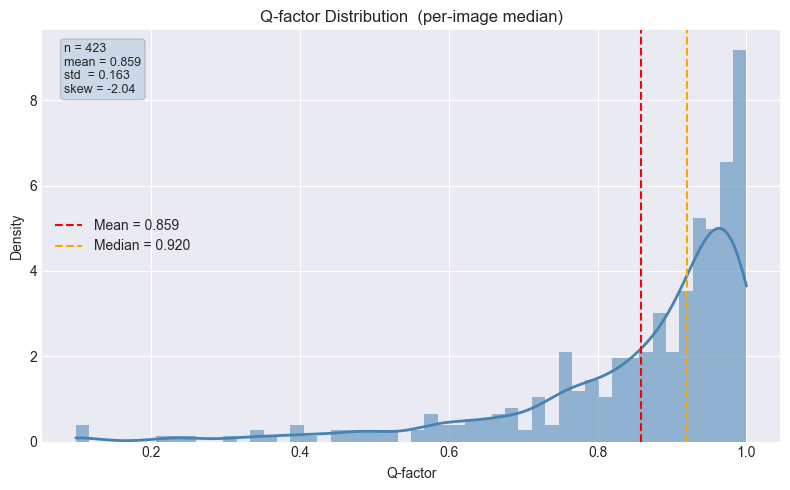

In [35]:
vals  = img['q_median'].values
color = 'steelblue'

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(vals, bins=50, density=True, color=color, alpha=0.55)
kde = gaussian_kde(vals, bw_method=0.2)
xk  = np.linspace(vals.min(), vals.max(), 400)
ax.plot(xk, kde(xk), color=color, linewidth=2)
ax.axvline(vals.mean(),      color='red',    linestyle='--', linewidth=1.5,
           label=f'Mean = {vals.mean():.3f}')
ax.axvline(np.median(vals),  color='orange', linestyle='--', linewidth=1.5,
           label=f'Median = {np.median(vals):.3f}')
stats = (f'n = {len(vals):,}\n'
         f'mean = {vals.mean():.3f}\n'
         f'std  = {vals.std():.3f}\n'
         f'skew = {pd.Series(vals).skew():.2f}')
ax.text(0.03, 0.97, stats, transform=ax.transAxes, va='top', fontsize=9,
        bbox=dict(boxstyle='round', alpha=0.15))
ax.set_xlabel('Q-factor')
ax.set_ylabel('Density')
ax.set_title('Q-factor Distribution  (per-image median)')
ax.legend()
plt.tight_layout()
plt.show()


## 3. Ablated Area (A) Distribution
Per-slice ablated cross-sectional area. Units: nm·µm.

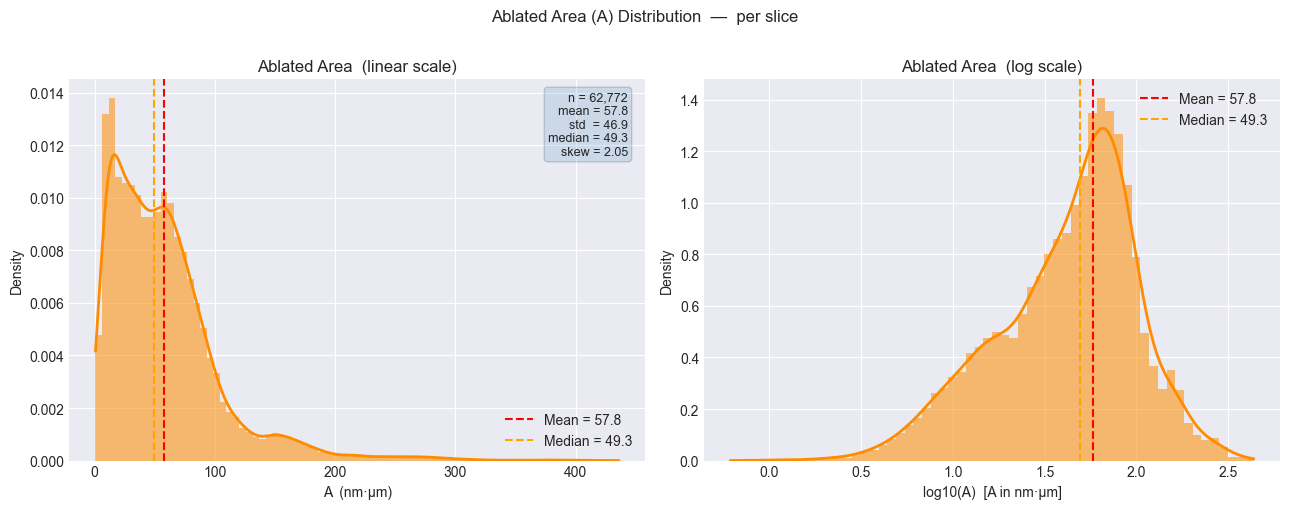

In [36]:
vals  = df['A'].values
color = 'darkorange'

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Linear scale
ax = axes[0]
ax.hist(vals, bins=80, density=True, color=color, alpha=0.55)
kde = gaussian_kde(vals, bw_method=0.15)
xk  = np.linspace(vals.min(), vals.max(), 400)
ax.plot(xk, kde(xk), color=color, linewidth=2)
ax.axvline(vals.mean(),     color='red',    linestyle='--', linewidth=1.5,
           label=f'Mean = {vals.mean():.1f}')
ax.axvline(np.median(vals), color='orange', linestyle='--', linewidth=1.5,
           label=f'Median = {np.median(vals):.1f}')
ax.set_xlabel('A  (nm·µm)')
ax.set_ylabel('Density')
ax.set_title('Ablated Area  (linear scale)')
ax.legend()

# Log scale (reveals shape of skewed distribution better)
ax = axes[1]
log_vals = np.log10(vals)
ax.hist(log_vals, bins=60, density=True, color=color, alpha=0.55)
kde2 = gaussian_kde(log_vals, bw_method=0.2)
xk2  = np.linspace(log_vals.min(), log_vals.max(), 400)
ax.plot(xk2, kde2(xk2), color=color, linewidth=2)
ax.axvline(np.log10(vals.mean()),     color='red',    linestyle='--', linewidth=1.5,
           label=f'Mean = {vals.mean():.1f}')
ax.axvline(np.log10(np.median(vals)), color='orange', linestyle='--', linewidth=1.5,
           label=f'Median = {np.median(vals):.1f}')
ax.set_xlabel('log10(A)  [A in nm·µm]')
ax.set_ylabel('Density')
ax.set_title('Ablated Area  (log scale)')
ax.legend()

stats = (f'n = {len(vals):,}\n'
         f'mean = {vals.mean():.1f}\n'
         f'std  = {vals.std():.1f}\n'
         f'median = {np.median(vals):.1f}\n'
         f'skew = {pd.Series(vals).skew():.2f}')
axes[0].text(0.97, 0.97, stats, transform=axes[0].transAxes, va='top', ha='right',
             fontsize=9, bbox=dict(boxstyle='round', alpha=0.15))

plt.suptitle('Ablated Area (A) Distribution  —  per slice', y=1.01)
plt.tight_layout()
plt.show()


## 4. Redeposited Area (R) Distribution
Per-slice redeposited cross-sectional area. Units: nm·µm.

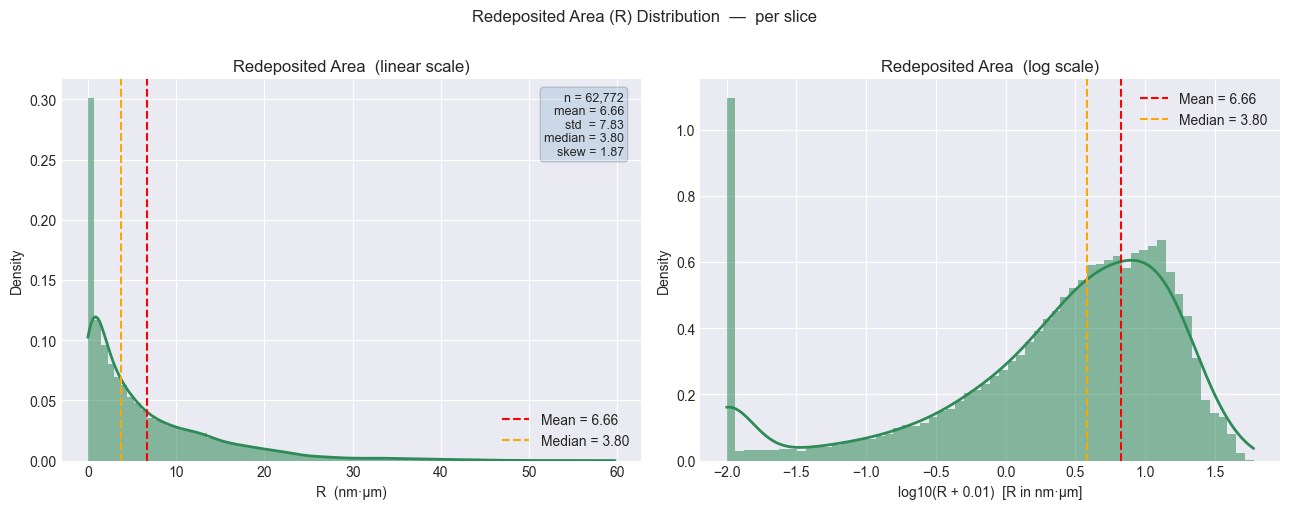

In [37]:
vals  = df['R'].values
color = 'seagreen'

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Linear scale
ax = axes[0]
ax.hist(vals, bins=80, density=True, color=color, alpha=0.55)
kde = gaussian_kde(vals, bw_method=0.15)
xk  = np.linspace(vals.min(), vals.max(), 400)
ax.plot(xk, kde(xk), color=color, linewidth=2)
ax.axvline(vals.mean(),     color='red',    linestyle='--', linewidth=1.5,
           label=f'Mean = {vals.mean():.2f}')
ax.axvline(np.median(vals), color='orange', linestyle='--', linewidth=1.5,
           label=f'Median = {np.median(vals):.2f}')
ax.set_xlabel('R  (nm·µm)')
ax.set_ylabel('Density')
ax.set_title('Redeposited Area  (linear scale)')
ax.legend()

# Log scale
ax = axes[1]
log_vals = np.log10(vals + 0.01)   # +0.01 to handle near-zero R values
ax.hist(log_vals, bins=60, density=True, color=color, alpha=0.55)
kde2 = gaussian_kde(log_vals, bw_method=0.2)
xk2  = np.linspace(log_vals.min(), log_vals.max(), 400)
ax.plot(xk2, kde2(xk2), color=color, linewidth=2)
ax.axvline(np.log10(vals.mean() + 0.01),     color='red',    linestyle='--', linewidth=1.5,
           label=f'Mean = {vals.mean():.2f}')
ax.axvline(np.log10(np.median(vals) + 0.01), color='orange', linestyle='--', linewidth=1.5,
           label=f'Median = {np.median(vals):.2f}')
ax.set_xlabel('log10(R + 0.01)  [R in nm·µm]')
ax.set_ylabel('Density')
ax.set_title('Redeposited Area  (log scale)')
ax.legend()

stats = (f'n = {len(vals):,}\n'
         f'mean = {vals.mean():.2f}\n'
         f'std  = {vals.std():.2f}\n'
         f'median = {np.median(vals):.2f}\n'
         f'skew = {pd.Series(vals).skew():.2f}')
axes[0].text(0.97, 0.97, stats, transform=axes[0].transAxes, va='top', ha='right',
             fontsize=9, bbox=dict(boxstyle='round', alpha=0.15))

plt.suptitle('Redeposited Area (R) Distribution  —  per slice', y=1.01)
plt.tight_layout()
plt.show()


## 5. Removed Material Volume
Per-image total removed volume, derived from the ablated area integral:

$$V_{image} = \sum_{slices} A_i \times w_{slice} \;\; [\mathrm{nm \cdot \mu m^2}] \div 1000 = V \;[\mathrm{\mu m^3}]$$

where $A_i$ is the ablated cross-sectional area per slice (nm·µm) and
$w_{slice}$ = 1.0 µm is the slice width used during extraction.

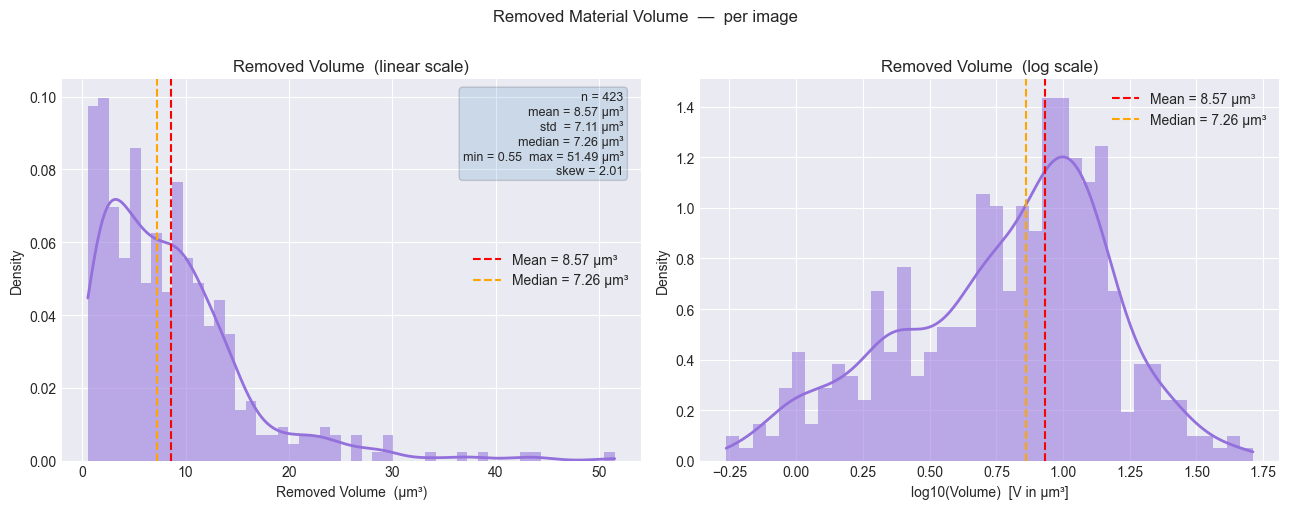

In [38]:
vals  = img['volume_um3'].values
color = 'mediumpurple'

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Linear scale
ax = axes[0]
ax.hist(vals, bins=50, density=True, color=color, alpha=0.55)
kde = gaussian_kde(vals, bw_method=0.25)
xk  = np.linspace(vals.min(), vals.max(), 400)
ax.plot(xk, kde(xk), color=color, linewidth=2)
ax.axvline(vals.mean(),     color='red',    linestyle='--', linewidth=1.5,
           label=f'Mean = {vals.mean():.2f} µm³')
ax.axvline(np.median(vals), color='orange', linestyle='--', linewidth=1.5,
           label=f'Median = {np.median(vals):.2f} µm³')
ax.set_xlabel('Removed Volume  (µm³)')
ax.set_ylabel('Density')
ax.set_title('Removed Volume  (linear scale)')
ax.legend()

# Log scale
ax = axes[1]
log_vals = np.log10(vals)
ax.hist(log_vals, bins=40, density=True, color=color, alpha=0.55)
kde2 = gaussian_kde(log_vals, bw_method=0.25)
xk2  = np.linspace(log_vals.min(), log_vals.max(), 400)
ax.plot(xk2, kde2(xk2), color=color, linewidth=2)
ax.axvline(np.log10(vals.mean()),     color='red',    linestyle='--', linewidth=1.5,
           label=f'Mean = {vals.mean():.2f} µm³')
ax.axvline(np.log10(np.median(vals)), color='orange', linestyle='--', linewidth=1.5,
           label=f'Median = {np.median(vals):.2f} µm³')
ax.set_xlabel('log10(Volume)  [V in µm³]')
ax.set_ylabel('Density')
ax.set_title('Removed Volume  (log scale)')
ax.legend()

stats = (f'n = {len(vals):,}\n'
         f'mean = {vals.mean():.2f} µm³\n'
         f'std  = {vals.std():.2f} µm³\n'
         f'median = {np.median(vals):.2f} µm³\n'
         f'min = {vals.min():.2f}  max = {vals.max():.2f} µm³\n'
         f'skew = {pd.Series(vals).skew():.2f}')
axes[0].text(0.97, 0.97, stats, transform=axes[0].transAxes, va='top', ha='right',
             fontsize=9, bbox=dict(boxstyle='round', alpha=0.15))

plt.suptitle('Removed Material Volume  —  per image', y=1.01)
plt.tight_layout()
plt.show()


## 6. Summary Statistics

In [39]:
    rows = [
    {'quantity': 'Q-factor',          'level': 'per-image', 'unit': '—',       'n': len(img),
     'mean': img['q_median'].mean(),   'std': img['q_median'].std(),
     'median': img['q_median'].median(),'min': img['q_median'].min(), 'max': img['q_median'].max(),
     'skew': img['q_median'].skew()},
    {'quantity': 'Ablated area A',      'level': 'per-slice', 'unit': 'nm·µm', 'n': len(df),
     'mean': df['A'].mean(),            'std': df['A'].std(),
     'median': df['A'].median(),        'min': df['A'].min(),  'max': df['A'].max(),
     'skew': df['A'].skew()},
    {'quantity': 'Redeposited area R',  'level': 'per-slice', 'unit': 'nm·µm', 'n': len(df),
     'mean': df['R'].mean(),            'std': df['R'].std(),
     'median': df['R'].median(),        'min': df['R'].min(),  'max': df['R'].max(),
     'skew': df['R'].skew()},
    {'quantity': 'Removed volume',      'level': 'per-image', 'unit': 'µm³',     'n': len(img),
     'mean': img['volume_um3'].mean(),  'std': img['volume_um3'].std(),
     'median': img['volume_um3'].median(),'min': img['volume_um3'].min(), 'max': img['volume_um3'].max(),
     'skew': img['volume_um3'].skew()},
]

summary = pd.DataFrame(rows).set_index('quantity')
float_cols = ['mean','std','median','min','max','skew']
print(summary.to_string(float_format=lambda x: f'{x:.3f}'))


                        level   unit      n   mean    std  median   min     max   skew
quantity                                                                              
Q-factor            per-image      —    423  0.859  0.163   0.920 0.099   1.000 -2.041
Ablated area A      per-slice  nm·µm  62772 57.780 46.893  49.328 0.612 436.215  2.050
Redeposited area R  per-slice  nm·µm  62772  6.664  7.829   3.799 0.000  59.720  1.869
Removed volume      per-image    µm³    423  8.574  7.115   7.257 0.547  51.493  2.013


## 7. Q-factor vs Scan Speed and Number of Passes

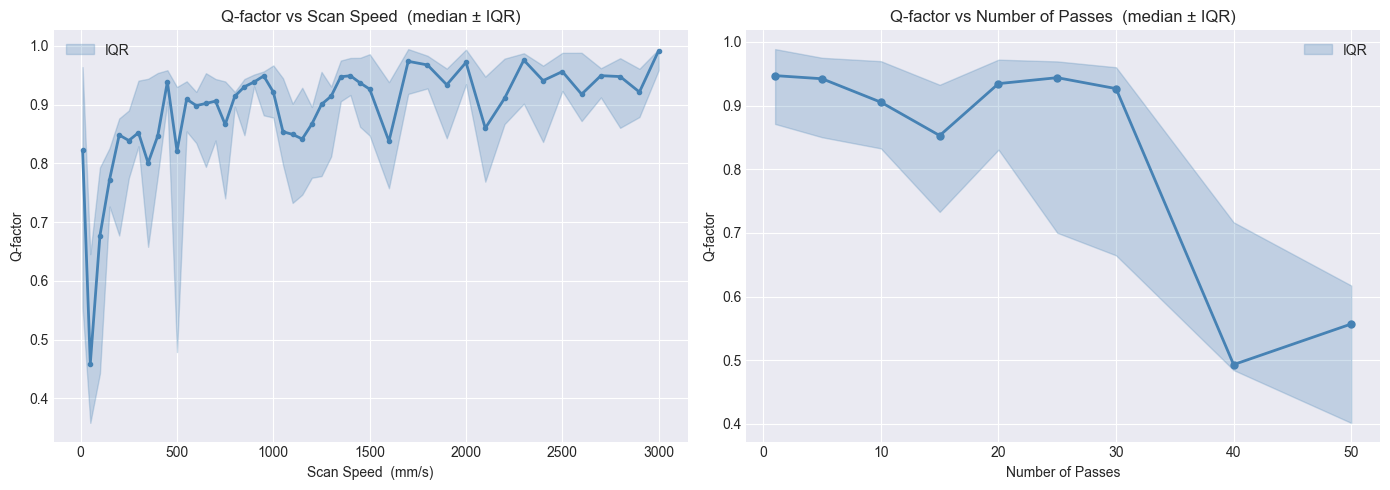

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Q vs Scan Speed
ax = axes[0]
grp   = img.groupby('scan_speed')['q_median']
med   = grp.median()
q1    = grp.quantile(0.25)
q3    = grp.quantile(0.75)
ax.plot(med.index, med.values, color='steelblue', linewidth=2, marker='o', markersize=3)
ax.fill_between(med.index, q1.values, q3.values, alpha=0.25, color='steelblue', label='IQR')
ax.set_xlabel('Scan Speed  (mm/s)')
ax.set_ylabel('Q-factor')
ax.set_title('Q-factor vs Scan Speed  (median ± IQR)')
ax.legend()

# Q vs n_pass
ax = axes[1]
grp2  = img.groupby('n_pass')['q_median']
med2  = grp2.median()
q1_2  = grp2.quantile(0.25)
q3_2  = grp2.quantile(0.75)
ax.plot(med2.index, med2.values, color='steelblue', linewidth=2, marker='o', markersize=5)
ax.fill_between(med2.index, q1_2.values, q3_2.values, alpha=0.25, color='steelblue', label='IQR')
ax.set_xlabel('Number of Passes')
ax.set_ylabel('Q-factor')
ax.set_title('Q-factor vs Number of Passes  (median ± IQR)')
ax.legend()

plt.tight_layout()
plt.show()


## 8. Removed Volume vs Scan Speed and Number of Passes

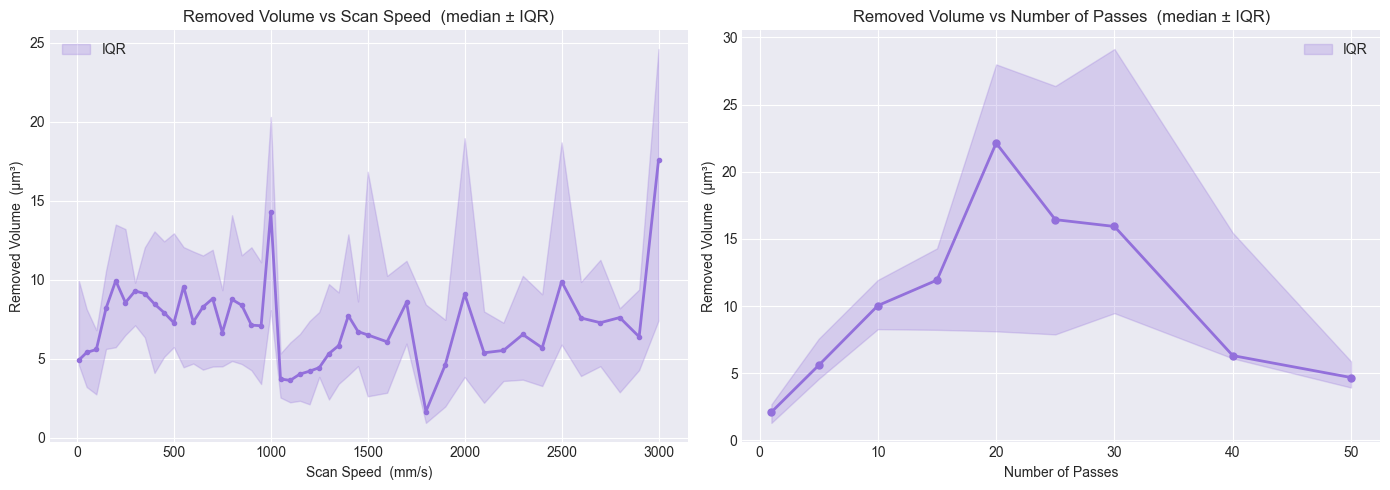

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Volume vs Scan Speed
ax = axes[0]
grp   = img.groupby('scan_speed')['volume_um3']
med   = grp.median()
q1    = grp.quantile(0.25)
q3    = grp.quantile(0.75)
ax.plot(med.index, med.values, color='mediumpurple', linewidth=2, marker='o', markersize=3)
ax.fill_between(med.index, q1.values, q3.values, alpha=0.25, color='mediumpurple', label='IQR')
ax.set_xlabel('Scan Speed  (mm/s)')
ax.set_ylabel('Removed Volume  (µm³)')
ax.set_title('Removed Volume vs Scan Speed  (median ± IQR)')
ax.legend()

# Volume vs n_pass
ax = axes[1]
grp2  = img.groupby('n_pass')['volume_um3']
med2  = grp2.median()
q1_2  = grp2.quantile(0.25)
q3_2  = grp2.quantile(0.75)
ax.plot(med2.index, med2.values, color='mediumpurple', linewidth=2, marker='o', markersize=5)
ax.fill_between(med2.index, q1_2.values, q3_2.values, alpha=0.25, color='mediumpurple', label='IQR')
ax.set_xlabel('Number of Passes')
ax.set_ylabel('Removed Volume  (µm³)')
ax.set_title('Removed Volume vs Number of Passes  (median ± IQR)')
ax.legend()

plt.tight_layout()
plt.show()


## 9. Intra-image Q Uniformity
For each image, compute the standard deviation of Q across its slices.
Low std = uniform quality along the trench. High std = patchy.

count    423.0000
mean       0.0913
std        0.0765
min        0.0000
25%        0.0328
50%        0.0615
75%        0.1325
max        0.3152


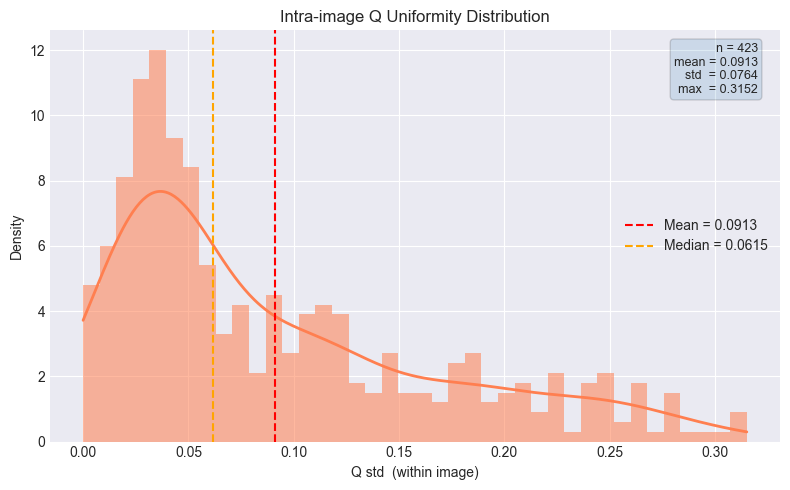

In [42]:
# Per-image Q std
q_stats = df.groupby('filename')['q_factor'].agg(['std', 'median']).reset_index()
q_stats.columns = ['filename', 'q_std', 'q_med_check']
img = img.merge(q_stats[['filename', 'q_std']], on='filename')

print(img['q_std'].describe().round(4).to_string())

# Distribution of Q std
vals  = img['q_std'].values
color = 'coral'

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(vals, bins=40, density=True, color=color, alpha=0.55)
kde = gaussian_kde(vals, bw_method=0.3)
xk  = np.linspace(vals.min(), vals.max(), 400)
ax.plot(xk, kde(xk), color=color, linewidth=2)
ax.axvline(vals.mean(),     color='red',    linestyle='--', linewidth=1.5,
           label=f'Mean = {vals.mean():.4f}')
ax.axvline(np.median(vals), color='orange', linestyle='--', linewidth=1.5,
           label=f'Median = {np.median(vals):.4f}')
stats = (f'n = {len(vals)}\n'
         f'mean = {vals.mean():.4f}\n'
         f'std  = {vals.std():.4f}\n'
         f'max  = {vals.max():.4f}')
ax.text(0.97, 0.97, stats, transform=ax.transAxes, va='top', ha='right',
        fontsize=9, bbox=dict(boxstyle='round', alpha=0.15))
ax.set_xlabel('Q std  (within image)')
ax.set_ylabel('Density')
ax.set_title('Intra-image Q Uniformity Distribution')
ax.legend()
plt.tight_layout()
plt.show()


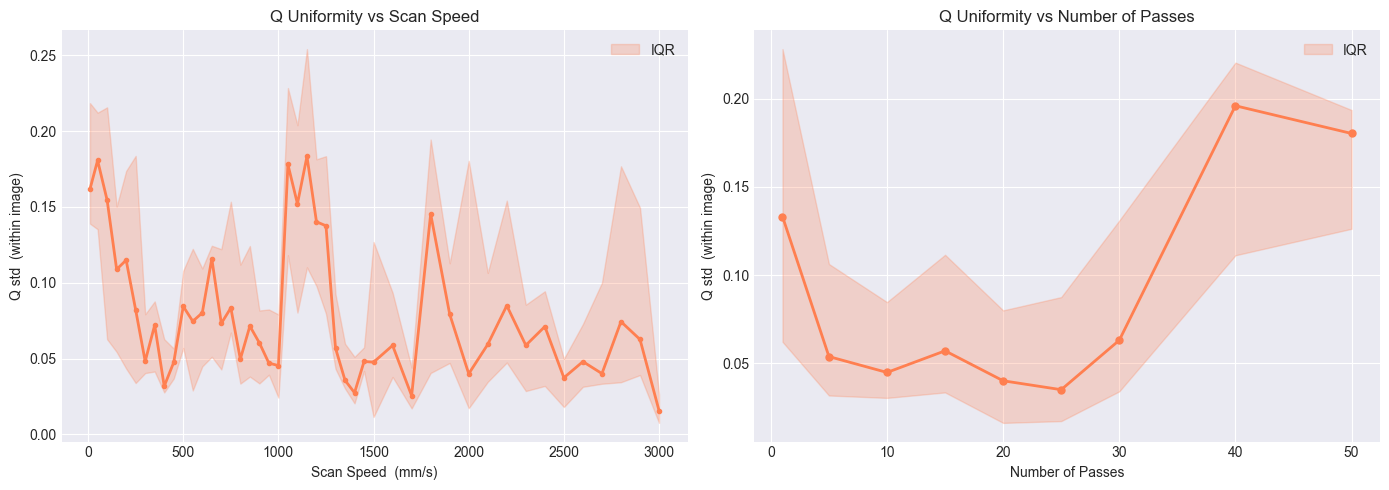

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Q std vs scan_speed
ax = axes[0]
grp  = img.groupby('scan_speed')['q_std']
med  = grp.median()
q1   = grp.quantile(0.25)
q3   = grp.quantile(0.75)
ax.plot(med.index, med.values, color='coral', linewidth=2, marker='o', markersize=3)
ax.fill_between(med.index, q1.values, q3.values, alpha=0.25, color='coral', label='IQR')
ax.set_xlabel('Scan Speed  (mm/s)')
ax.set_ylabel('Q std  (within image)')
ax.set_title('Q Uniformity vs Scan Speed')
ax.legend()

# Q std vs n_pass
ax = axes[1]
grp2 = img.groupby('n_pass')['q_std']
med2 = grp2.median()
q1_2 = grp2.quantile(0.25)
q3_2 = grp2.quantile(0.75)
ax.plot(med2.index, med2.values, color='coral', linewidth=2, marker='o', markersize=5)
ax.fill_between(med2.index, q1_2.values, q3_2.values, alpha=0.25, color='coral', label='IQR')
ax.set_xlabel('Number of Passes')
ax.set_ylabel('Q std  (within image)')
ax.set_title('Q Uniformity vs Number of Passes')
ax.legend()

plt.tight_layout()
plt.show()


## 10. Spatial Analysis Along the Trench
Each image is sliced along its length. Normalising `position_um` to [0, 1]
allows averaging across all images regardless of total trench length.
0 = start of scan, 1 = end of scan.

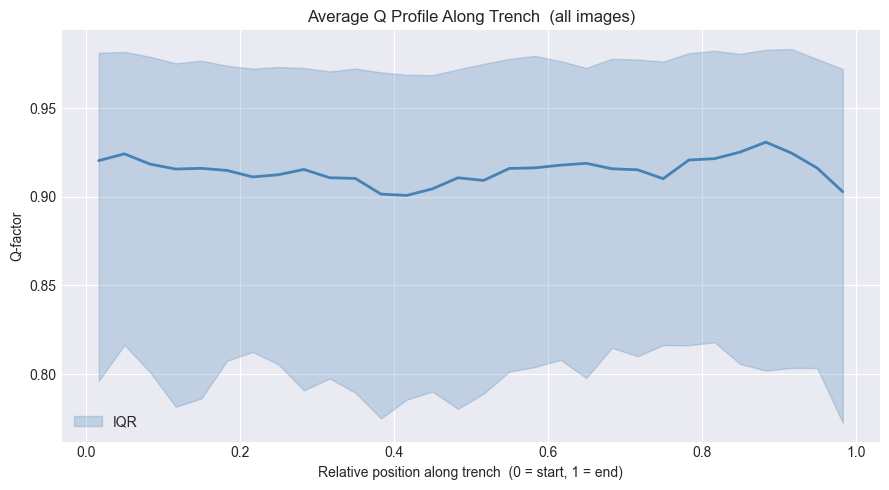

In [44]:
N_BINS = 30

# Relative position per image (vectorised)
pos_min = df.groupby('filename')['position_um'].transform('min')
pos_max = df.groupby('filename')['position_um'].transform('max')
pos_rng = pos_max - pos_min
df = df.copy()
df['rel_pos'] = np.where(pos_rng > 0,
                         (df['position_um'] - pos_min) / pos_rng,
                         0.5)
df['pos_bin'] = (df['rel_pos'] * N_BINS).astype(int).clip(0, N_BINS - 1)
bin_x = np.arange(N_BINS) / N_BINS + 0.5 / N_BINS   # bin centres 0..1

# Overall median Q profile
profile     = df.groupby('pos_bin')['q_factor'].median()
profile_q1  = df.groupby('pos_bin')['q_factor'].quantile(0.25)
profile_q3  = df.groupby('pos_bin')['q_factor'].quantile(0.75)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(bin_x, profile.values, color='steelblue', linewidth=2)
ax.fill_between(bin_x, profile_q1.values, profile_q3.values,
                alpha=0.25, color='steelblue', label='IQR')
ax.set_xlabel('Relative position along trench  (0 = start, 1 = end)')
ax.set_ylabel('Q-factor')
ax.set_title('Average Q Profile Along Trench  (all images)')
ax.legend()
plt.tight_layout()
plt.show()


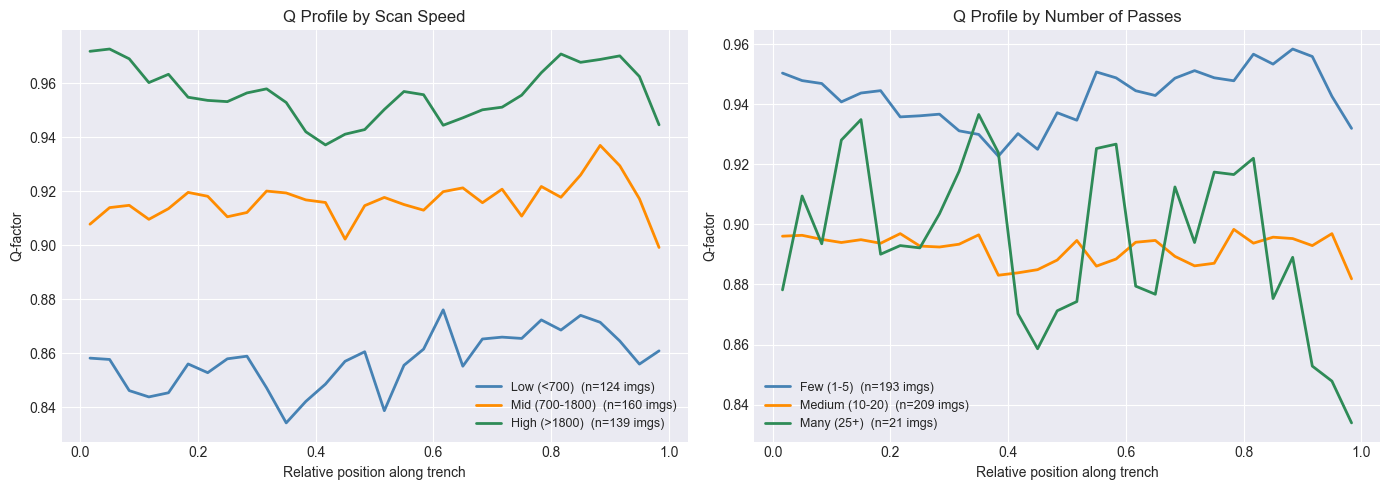

In [45]:
# Join process params onto slice-level data
df_sp = df.merge(img[['filename', 'scan_speed', 'n_pass']], on='filename')

# Scan speed groups: low / mid / high thirds
speed_labels = ['Low (<700)', 'Mid (700-1800)', 'High (>1800)']
df_sp['speed_grp'] = pd.cut(df_sp['scan_speed'],
                             bins=[0, 700, 1800, 9999],
                             labels=speed_labels)

# n_pass groups
pass_labels = ['Few (1-5)', 'Medium (10-20)', 'Many (25+)']
df_sp['pass_grp'] = pd.cut(df_sp['n_pass'],
                            bins=[0, 5, 20, 999],
                            labels=pass_labels)

colors_3 = ['steelblue', 'darkorange', 'seagreen']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Q profile by scan_speed group
ax = axes[0]
for label, color in zip(speed_labels, colors_3):
    sub = df_sp[df_sp['speed_grp'] == label]
    if sub.empty:
        continue
    prof = sub.groupby('pos_bin')['q_factor'].median()
    ax.plot(bin_x[:len(prof)], prof.values, color=color, linewidth=2,
            label=f'{label}  (n={sub["filename"].nunique()} imgs)')
ax.set_xlabel('Relative position along trench')
ax.set_ylabel('Q-factor')
ax.set_title('Q Profile by Scan Speed')
ax.legend(fontsize=9)

# Q profile by n_pass group
ax = axes[1]
for label, color in zip(pass_labels, colors_3):
    sub = df_sp[df_sp['pass_grp'] == label]
    if sub.empty:
        continue
    prof = sub.groupby('pos_bin')['q_factor'].median()
    ax.plot(bin_x[:len(prof)], prof.values, color=color, linewidth=2,
            label=f'{label}  (n={sub["filename"].nunique()} imgs)')
ax.set_xlabel('Relative position along trench')
ax.set_ylabel('Q-factor')
ax.set_title('Q Profile by Number of Passes')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()
